In [2]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.signal.preprocess import *
from glob import glob
import torchaudio
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import *
import os
import torchinfo
import core.nn.dataset

In [3]:

# def sigFilter(sig, sr, lowpass_cutoff_in_hz, filterX, filterY):
#     # Perform a real-valued fast Fourier transform.
#     rfft = torch.fft.rfft(sig)

#     # Calculate the index for the low pass filter cutoff.
#     lowwpassLocation = int(lowpass_cutoff_in_hz / (sr / sig.shape[-1]))

#     # Apply the low pass filter by zeroing out frequencies beyond the cutoff.
#     rfft[:, lowwpassLocation:] = 0

#     # Apply custom filters to the FFT of the signal.
#     rfftX = rfft[0, :] * filterX
#     rfftY = rfft[1, :] * filterY

#     # Stack the filtered FFT components.
#     rfft = torch.stack((rfftX, rfftY))

#     # Perform an inverse real-valued FFT to get back to the time domain.
#     sig = torch.fft.irfft(rfft)

#     return sig
#         # Normalize wavA and wavB.
#         wavA = wavA / torch.sqrt(torch.sum(wavA ** 2, dim=-1, keepdim=True))
#         wavB = wavB / torch.sqrt(torch.sum(wavB ** 2, dim=-1, keepdim=True))

In [4]:
import logging
logging.basicConfig(level=logging.INFO)

In [8]:
vctkds = torchaudio.datasets.VCTK_092(root="vctk/", download=False)
ds2 = core.nn.dataset.VCTK_CSV("/home/mo/data/MICEMOUSE/gen/csv")
paired_ds = core.nn.dataset.PairedAudioDataset(vctkds, ds2)

INFO:root:Initializing PairedAudioDataset...


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [01:52<00:00,  1.78it/s]


In [81]:
N = 200
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# i = 0
# offsets = torch.zeros((N), dtype=torch.int64)
# with torch.no_grad():
    # with tqdm(total=N) as pbar:
        # for gtWav, mouseWav, _, _, _, _ in paired_ds:
            # gtWav = gtWav[0, :].to(device)
            # # duplicate gtWav to two channels
            # gtWav = torch.stack((gtWav, gtWav))
            # gtWav = gtWav / torch.sqrt(torch.sum(gtWav ** 2))
            # mouseWav = mouseWav.to(device)
            # mouseWav = mouseWav / torch.sqrt(torch.sum(mouseWav ** 2))
            # corr = torch.nn.functional.conv1d(mouseWav[None, :], gtWav[None, :])
            # corr = corr.flatten()
            # offset = torch.argmax(corr)
            # offsets[i] = offset
            # i += 1
            # pbar.update(1)
            # # if i == N:
            #     break
# from scipy import stats
# offsets = torch.tensor(offsets, dtype=torch.float32)
# mean_offset = offsets.mean()
# sigma = offsets.std()
# K = len(offsets)
# t_score = stats.t.ppf((1 + 0.95) / 2, K - 1)
# margin_of_error = t_score * sigma / np.sqrt(K)

# lower_bound = mean_offset - margin_of_error
# upper_bound = mean_offset + margin_of_error
# # remove outliers
# offsets = offsets[offsets > lower_bound]
# offsets = offsets[offsets < upper_bound]
# mean_offset = int(offsets.mean())
# # plot histogram
# plt.hist(offsets, bins=100)
# plt.show()

mean_offset = 52639
print(f"mean offset: {mean_offset}")

mean offset: 52639


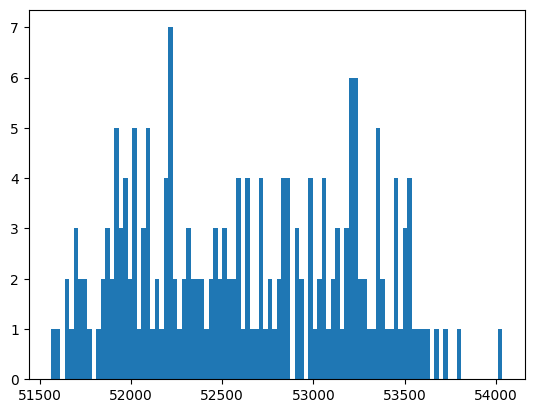

(tensor(51973.), 52639)

In [78]:
def trim_sig(gt_sig, ms_sig, offset = mean_offset):
    ms_sig = ms_sig[:, offset:offset+gt_sig.shape[-1]]
    return gt_sig, ms_sig

In [79]:
def getSpectrum(signal):
    signal = signal / torch.sqrt(torch.sum(signal ** 2))
    signalSpec = torch.fft.rfft(signal).abs()
    return signalSpec

In [85]:
maxLen = 0
i = 0
with tqdm(total=N) as pbar:
    for gtWav, mouseWav, _, _, _, _ in paired_ds:
        gtWav, mouseWav = trim_sig(gtWav, mouseWav)
        maxLen = max(maxLen, gtWav.shape[-1])
        pbar.update(1)
        i += 1
        if i == N:
            break
print(f"maxLen: {maxLen}")

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:01<00:00, 144.74it/s]

maxLen: 583417


In [86]:
Fs = 16000

/home/mo/.local/lib/python3.10/site-packages/scipy/signal/_savitzky_golay.py:339: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(np.float64)


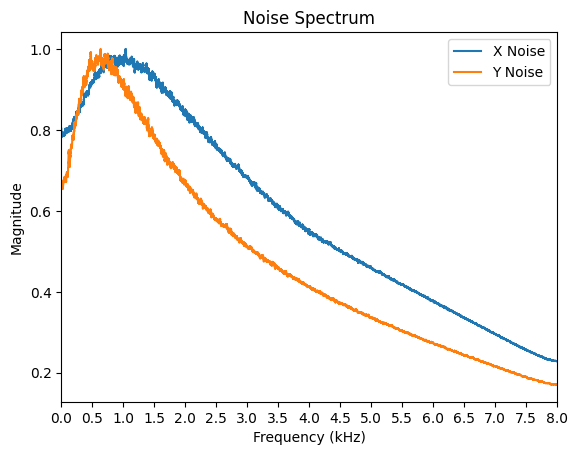

In [93]:
tnoise, noiseX, noiseY = processFromFile("/home/mo/data/MICEMOUSE/gen/noise/noise_2023-11-03_21-00-40.csv", skipPCA = True)
# trim to maxLen
k = torch.ceil(torch.tensor(noiseX.shape[0] / maxLen, dtype=torch.long)).item()
xz = torch.zeros((k * maxLen, ), dtype=torch.complex64)
xz = noiseX[:xz.shape[0]]
xz = xz.reshape((k, maxLen))
yz = torch.zeros((k * maxLen, ), dtype=torch.complex64)
yz = noiseY[:yz.shape[0]]
yz = yz.reshape((k, maxLen))
xzSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64)
yzSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64)
for x, y in zip(xz, yz):
    xzSpec += getSpectrum(x) / k
    yzSpec += getSpectrum(y) / k
filteredx = savgol_filter((xzSpec), 1001, 3)
noiseXSpecSmooth = torch.tensor(filteredx)
noiseXSpecSmooth = noiseXSpecSmooth / noiseXSpecSmooth.abs().max()
plt.plot(noiseXSpecSmooth.abs(), label="X Noise")
filteredy = savgol_filter((yzSpec), 1001, 3)
noiseYSpecSmooth = torch.tensor(filteredy)
noiseYSpecSmooth = noiseYSpecSmooth / noiseYSpecSmooth.abs().max()
plt.plot(noiseYSpecSmooth.abs(), label="Y Noise")
xlim = maxLen //2 + 1
xlimHz = xlim * Fs / maxLen
xticksHz = torch.arange(0, xlimHz + 1, 500)
xticks = xticksHz * maxLen / Fs
xticks_labels = [f"{x/1000:.1f}" for x in xticksHz]
plt.xlim(0, xlim)
plt.xticks(xticks, xticks_labels)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude")
plt.legend()
plt.title("Noise Spectrum")
plt.show()


In [89]:
gtSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64) # ground truth spectrum
mouseXSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64) # mouse spectrum
mouseYSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64) # mouse spectrum
i = 0
with tqdm(total = N) as pbar:
    for gtSig, mouseSig, _, _, _, _ in paired_ds:
        # pad gtSig and mouseSig
        gtSig, mouseSig = trim_sig(gtSig, mouseSig)
        gtSig = torch.nn.functional.pad(gtSig, (0, maxLen - gtSig.shape[-1]))
        mouseSig = torch.nn.functional.pad(mouseSig, (0, maxLen - mouseSig.shape[-1]))
        # Pad, FFT, normalize, and accumulate
        gtSpec += getSpectrum(gtSig[0, :]) / N # divide here instead of outside the loop to avoid numerical issues (common when N is large)
        mouseXSpec += getSpectrum(mouseSig[0, :]) / N
        mouseYSpec += getSpectrum(mouseSig[1, :]) / N
        pbar.update(1)
        i += 1
        if i == N:
            break

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:28<00:00,  6.97it/s]


/home/mo/.local/lib/python3.10/site-packages/scipy/signal/_savitzky_golay.py:339: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(np.float64)
/home/mo/mambaforge/envs/micemouse/lib/python3.10/site-packages/torch/_tensor.py:972: ComplexWarning: Casting complex values to real discards the imaginary part
  return self.numpy().astype(dtype, copy=False)


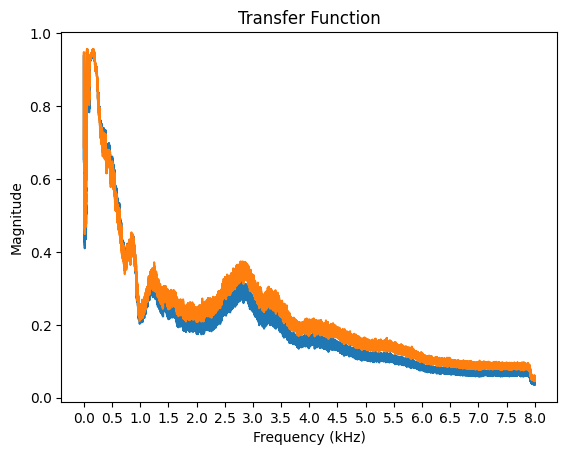

In [122]:
ratioX= mouseXSpec/noiseXSpecSmooth
ratioY= mouseYSpec/noiseYSpecSmooth
ratioX = savgol_filter(ratioX, 1001, 3)
ratioY = savgol_filter(ratioY, 1001, 3)
newNoiseSpecX = noiseXSpecSmooth * (ratioX.mean())
newNoiseSpecY = noiseYSpecSmooth * (ratioY.mean())
HX= gtSpec / (gtSpec + newNoiseSpecX)
HY= gtSpec / (gtSpec + newNoiseSpecY)
plt.plot(HX)
plt.plot(HY)
xlim = maxLen //2 + 1
xlimHz = xlim * Fs / maxLen
xticksHz = torch.arange(0, xlimHz + 1, 500)
xticks = xticksHz * maxLen / Fs
xticks_labels = [f"{x/1000:.1f}" for x in xticksHz]
plt.xlim(0, xlim)
plt.xticks(xticks, xticks_labels)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude")
plt.title("Transfer Function")
plt.show()

In [123]:
def filter_sig(gt_sig, ms_sig, HX, HY, cuttoff_in_hz = 8000):
    _, ms_sig = trim_sig(gt_sig, ms_sig)
    old_len = gt_sig.shape[-1]
    ms_sig = torch.nn.functional.pad(ms_sig, (0, maxLen - ms_sig.shape[-1]))
    ms_sig = ms_sig / torch.sqrt(torch.sum(ms_sig ** 2))
    gt_sig = torch.nn.functional.pad(gt_sig, (0, maxLen - gt_sig.shape[-1]))
    gt_sig = gt_sig / torch.sqrt(torch.sum(gt_sig ** 2))
    ms_sig = torch.fft.rfft(ms_sig)
    # cuttoff_idx = int(maxLen * cuttoff_in_hz / Fs)
    # ms_sig[:, cuttoff_idx:] = 0
    ms_sig[0, :] = ms_sig[0, :] * HX
    ms_sig[1, :] = ms_sig[1, :] * HY
    ms_sig = torch.fft.irfft(ms_sig)
    ms_sig = ms_sig[:, :old_len]
    gt_sig = gt_sig[:, :old_len]
    return gt_sig, ms_sig

In [130]:
X, Y, _, _, _, _ = paired_ds[0]
X, Y = filter_sig(X, Y, HX, HY)

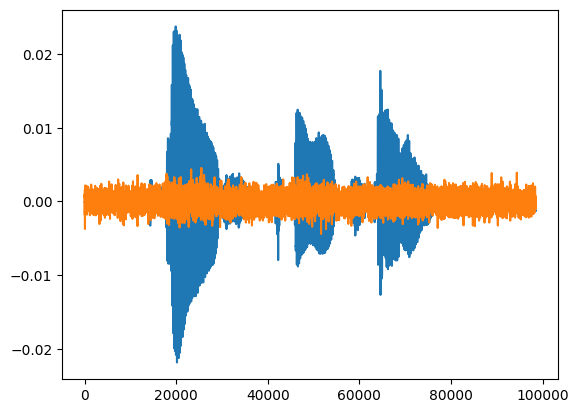

In [131]:
plt.plot(X[0, :].numpy())
plt.plot(Y.mean(dim = 0).numpy())

In [160]:
batch_size = 2
# Split into train and test
split = 0.85
lenTrain = int(len(paired_ds) * split)
lenTest = len(paired_ds) - lenTrain
# select lenTrain random indices
np.random.seed(0) # for reproducibility
idxtrain = np.random.choice(len(paired_ds), lenTrain, replace=False)
idxtest = np.setdiff1d(np.arange(len(paired_ds)), idxtrain)
train = torch.utils.data.Subset(paired_ds, idxtrain)
test = torch.utils.data.Subset(paired_ds, idxtest)

def collate(batch):
    A, B = [], []
    for w, m, _, _, _, _ in batch:
        w, m = trim_sig(w, m)   
        # Choose one of filter_sig or trim_sig
        # w, m = filter_sig(w, m, HX, HY)
        A.append(w)
        B.append(m)    
    maxLenLocal = max([x.shape[-1] for x in A])
    A = torch.stack([torch.nn.functional.pad(x, (0, maxLenLocal - x.shape[-1])) for x in A])
    B = torch.stack([torch.nn.functional.pad(x, (0, maxLenLocal - x.shape[-1])) for x in B])    
    return A, B

train_loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, collate_fn=collate)
test_loader = torch.utils.data.DataLoader(test, batch_size=batch_size, shuffle=False)

In [161]:
speaker_list = ['p225', 'p226','p227','p228', 'p229', 'p230', 'p231', 'p232', 'p233', 'p234', 'p236', 'p237', 'p238', 'p239', 'p240', 'p241', 'p243', 'p244', 'p245', 'p246', 'p247', 'p248', 'p249']
nSpeakers = len(speaker_list)
onehot_speaker = lambda x: torch.eye(nSpeakers)[speaker_list.index(x)]
# Is this a clean way to do this? Hell nah
# Is this efficient? Yes

In [163]:
for (waveformA, waveformB) in train_loader:
    print(waveformB.shape)
    break

torch.Size([3, 2, 129019])


In [164]:
import torch
from torch import nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1, init_features=32):
        super(UNet, self).__init__()
        
        features = init_features
        self.encoder1 = UNet._block(in_channels, features, name="enc1")
        self.pool1 = nn.MaxPool1d(kernel_size=4, stride=4)
        self.encoder2 = UNet._block(features, features * 2, name="enc2")
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.encoder3 = UNet._block(features * 2, features * 4, name="enc3")
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.encoder4 = UNet._block(features * 4, features * 8, name="enc4")
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.bottleneck = UNet._block(features * 8, features * 16, name="bottleneck")

        self.upconv4 = nn.ConvTranspose1d(features * 16, features * 8, kernel_size=2, stride=2)
        self.decoder4 = UNet._block((features * 8) * 2, features * 8, name="dec4")
        self.upconv3 = nn.ConvTranspose1d(features * 8, features * 4, kernel_size=2, stride=2)
        self.decoder3 = UNet._block((features * 4) * 2, features * 4, name="dec3")
        self.upconv2 = nn.ConvTranspose1d(features * 4, features * 2, kernel_size=2, stride=2)
        self.decoder2 = UNet._block((features * 2) * 2, features * 2, name="dec2")
        self.upconv1 = nn.ConvTranspose1d(features * 2, features, kernel_size=4, stride=4)
        self.decoder1 = UNet._block(features * 2, features, name="dec1")

        self.conv = nn.Conv1d(in_channels=features, out_channels=out_channels, kernel_size=1)

    @staticmethod
    def _block(in_channels, features, name):
        return nn.Sequential(
            nn.Conv1d(in_channels=in_channels, out_channels=features, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(num_features=features),
            nn.ReLU(inplace=True),
            nn.Conv1d(in_channels=features, out_channels=features, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(num_features=features),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        enc3 = self.encoder3(self.pool2(enc2))
        enc4 = self.encoder4(self.pool3(enc3))

        bottleneck = self.bottleneck(self.pool4(enc4))

        dec4 = self.upconv4(bottleneck)
        dec4 = self.center_crop(dec4, enc4.shape[2])
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)
        
        dec3 = self.upconv3(dec4)
        dec3 = self.center_crop(dec3, enc3.shape[2])
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = self.center_crop(dec2, enc2.shape[2])
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = self.center_crop(dec1, enc1.shape[2])
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)

        return self.conv(dec1)

    def center_crop(self, dec, enc_shape):
        dec_shape = dec.shape[2]
        trim_size = (dec_shape - enc_shape) // 2
        # trim_size can be negative, in that case, we need to pad
        
        if trim_size < 0:
            pad_size = -trim_size
            dec = F.pad(dec, (pad_size, pad_size + 1))
            return dec[:, :, pad_size:pad_size+enc_shape]        
        else:        
            return dec[:, :, trim_size:trim_size+enc_shape]

In [165]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)


# Assuming the use of MSE loss and Adam optimizer
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.MSELoss()

In [46]:
# torchinfo.summary(model, input_size=(1, 2, 264910))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 1, 264910]            --
├─Sequential: 1-1                        [1, 32, 264910]           --
│    └─Conv1d: 2-1                       [1, 32, 264910]           192
│    └─BatchNorm1d: 2-2                  [1, 32, 264910]           64
│    └─ReLU: 2-3                         [1, 32, 264910]           --
│    └─Conv1d: 2-4                       [1, 32, 264910]           3,072
│    └─BatchNorm1d: 2-5                  [1, 32, 264910]           64
│    └─ReLU: 2-6                         [1, 32, 264910]           --
├─MaxPool1d: 1-2                         [1, 32, 66227]            --
├─Sequential: 1-3                        [1, 64, 66227]            --
│    └─Conv1d: 2-7                       [1, 64, 66227]            6,144
│    └─BatchNorm1d: 2-8                  [1, 64, 66227]            128
│    └─ReLU: 2-9                         [1, 64, 66227]            --
│    └─

In [166]:
print_every = 100
num_epochs = 1  # for example, adjust as necessary
with tqdm(total=num_epochs * len(train_loader)) as pbar:
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for i, data in enumerate(train_loader, 0):
            # Unpack data
            inputs, labels = data[1], data[0]
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Print statistics
            running_loss += loss.item()
            if i % print_every == (print_every - 1):    # reset every 100 mini-batches
                running_loss = 0.0
            pbar.set_description(f'Epoch {epoch+1} Loss: {running_loss/(i % print_every + 1):.3f}')    
            pbar.update(1)

print('Finished Training')


  0%|          | 0/12431 [00:00<?, ?it/s]

Epoch 1 Loss: 0.143:   0%|          | 1/12431 [00:00<3:09:23,  1.09it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 36.00 MiB (GPU 0; 2.94 GiB total capacity; 1.61 GiB already allocated; 42.50 MiB free; 1.93 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [44]:
# Save model
torch.save(model.state_dict(), 'model_unet.pth')

In [51]:
# Test model
model.eval()
with torch.no_grad():
    for (waveformA, waveformB, _, _, _, _, _) in train_loader:
        outputs = model(waveformB.to(device))
        break

In [52]:
wav = outputs[1, :, :].cpu().detach()
torchaudio.save("test.wav", wav, 16000)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = model.to(device)
torchinfo.summary(net, (2, 2, 226209))

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [2, 1, 226209]            --
├─Sequential: 1-1                        [2, 32, 226209]           --
│    └─Conv1d: 2-1                       [2, 32, 226209]           192
│    └─BatchNorm1d: 2-2                  [2, 32, 226209]           64
│    └─ReLU: 2-3                         [2, 32, 226209]           --
│    └─Conv1d: 2-4                       [2, 32, 226209]           3,072
│    └─BatchNorm1d: 2-5                  [2, 32, 226209]           64
│    └─ReLU: 2-6                         [2, 32, 226209]           --
├─MaxPool1d: 1-2                         [2, 32, 56552]            --
├─Sequential: 1-3                        [2, 64, 56552]            --
│    └─Conv1d: 2-7                       [2, 64, 56552]            6,144
│    └─BatchNorm1d: 2-8                  [2, 64, 56552]            128
│    └─ReLU: 2-9                         [2, 64, 56552]            --
│    └─

In [83]:
N_EPOCHS = 10
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
with tqdm(range(N_EPOCHS)) as pbar:
    for epoch in pbar:
        for (waveform, _, _, speaker_id, _) in train_loader:
            waveform = waveform.to(device)
            waveform = torch.cat([waveform, waveform], dim=1)
            speaker_one_hot = (torch.stack([onehot_speaker(i) for i in speaker_id]))
            speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
            speaker_one_hot = speaker_one_hot.to(device)
            optimizer.zero_grad()
            output = net(waveform)
            loss = criterion(output, speaker_id)
            loss.backward()
            optimizer.step()
            pbar.set_description(f"Loss: {loss.item():.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

Loss: 0.0232: 100%|██████████| 10/10 [12:46<00:00, 76.66s/it]


100%|██████████| 84/84 [00:06<00:00, 12.24it/s]

Accuracy: 93.89%


In [87]:
net_ds2 = ConvNet2D(nSpeakers).to(device)
N_EPOCHS = 10
optimizerds2 = torch.optim.Adam(net_ds2.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
with tqdm(range(N_EPOCHS)) as pbar:
    for epoch in pbar:
        for (waveform, _, _, speaker_id, _) in train_ds2_loader:
            waveform = waveform.to(device)
            speaker_one_hot = (torch.stack([onehot_speaker(i) for i in speaker_id]))
            speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
            speaker_one_hot = speaker_one_hot.to(device)
            optimizerds2.zero_grad()
            output = net_ds2(waveform)
            loss = criterion(output, speaker_id)
            loss.backward()
            optimizerds2.step()
            pbar.set_description(f"Loss: {loss.item():.4f}")

Loss: 0.2234: 100%|██████████| 10/10 [13:38<00:00, 81.88s/it]


In [94]:
# save the models

torch.save(net.state_dict(), "convnet2d.pt")
torch.save(net_ds2.state_dict(), "convnet2d_ds2.pt")

In [95]:
accuracy = 0 
with torch.no_grad():
    for (waveform, _, _, speaker_id, _) in tqdm(test_loader):
        waveform = waveform.to(device)
        waveform = torch.cat([waveform, waveform], dim=1)
        speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
        output = net(waveform)
        accuracy += (output.argmax(1) == speaker_id).sum().item()
print(f"Accuracy: {accuracy / len(test_loader.dataset) * 100:.2f}%")

  0%|          | 0/84 [00:00<?, ?it/s]

100%|██████████| 84/84 [00:08<00:00,  9.84it/s]

Accuracy: 93.67%


In [96]:
accuracy = 0 
with torch.no_grad():
    for (waveform, _, _, speaker_id, _) in tqdm(test_ds2_loader):
        waveform = waveform.to(device)
        speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
        output = net_ds2(waveform)
        accuracy += (output.argmax(1) == speaker_id).sum().item()
print(f"Accuracy: {accuracy / len(test_ds2_loader.dataset) * 100:.2f}%")

100%|██████████| 84/84 [00:10<00:00,  8.26it/s]

Accuracy: 89.05%
